<h1>Sudoku</h1>

In [124]:
import matplotlib.pyplot as plt
import random, copy, math, os

<h4>Funkcja do wczytywania</h4>

In [5]:
def load_sudoku(filename):
    board = []
    
    with open(filename, 'r') as file:
        for line in file:
            line = line.strip()
            
                
            row = []
            for char in line:
                if char == 'x': row.append(0)
                else: row.append(int(char))
                    
            board.append(row)
            
    return board



<h4>Funkcja do wyświetlania</h4>

Wypełnione komurki zanacza niebieskim kolorem.

In [6]:
def draw_sudoku(initial_board, solved_board):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    def draw_board(ax, board, base_board=None, title=""):
        ax.set_xlim(0, 9)
        ax.set_ylim(0, 9)
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=16)
        
        for i in range(10):
            linewidth = 2.5 if i % 3 == 0 else 0.5
            ax.plot([0, 9], [i, i], color='black', linewidth=linewidth)
            ax.plot([i, i], [0, 9], color='black', linewidth=linewidth)
            
        for row in range(9):
            for col in range(9):
                val = board[row][col]
                if val != 0:
                    text_color = 'black'
                    if base_board and base_board[row][col] == 0:
                        text_color = 'blue'
                        
                    ax.text(col + 0.5, row + 0.5, str(val), 
                            ha='center', va='center', fontsize=16, color=text_color)

    draw_board(axes[0], initial_board, title="Initial Board")
    
    draw_board(axes[1], solved_board, base_board=initial_board, title="Solved Board")
    
    plt.tight_layout()
    
    
    plt.show()
    plt.close(fig)


<h4>Generacja losowych kwadratów</h4>
Zdecedowałem zrobić funkcję generacji następnego stanu, która obliczy tylko wartości w kolumnach oraz w wierszach, a w blokach ona wypełnia już gotowymi liczbami. To powinno prespieszyć progam.
Tu jest przedstawiona funkcja, która właśnie wypełnia te kwadraty 3x3.

In [8]:
def fill_blocks_and_get_movable(init_board):
    new_board = copy.deepcopy(init_board)
    movable_cells_by_block = [[] for _ in range(9)]
    
    for block_idx in range(9):
        start_row = (block_idx // 3) * 3
        start_col = (block_idx % 3) * 3
        
        fixed_numbers = set()
        empty_cells = []
        
        for r in range(start_row, start_row + 3):
            for c in range(start_col, start_col + 3):

                val = new_board[r][c]
                if val != 0: fixed_numbers.add(val)
                else: empty_cells.append((r, c))
                    
        all_numbers = set(range(1, 10))
        missing_numbers = list(all_numbers - fixed_numbers)
        
        random.shuffle(missing_numbers)
        

        for (r, c), num in zip(empty_cells, missing_numbers):
            new_board[r][c] = num
            movable_cells_by_block[block_idx].append((r, c))
            
    return new_board, movable_cells_by_block

<h4>Energia oraz tempertura</h4>

Pomocicze funkcji do wyliczania energii oraz funcja temperatury.


In [ ]:
def calculate_total_energy(board):
    cost = 0
    
    for i in range(9):
        row_unique = len(set(board[i]))
        cost += (9 - row_unique)
        
        col_values = [board[r][i] for r in range(9)]
        col_unique = len(set(col_values))
        cost += (9 - col_unique)
        
    return cost

def calculate_partial_energy(board, block_idx):
    cost = 0
    
    start_row = (block_idx // 3) * 3
    start_col = (block_idx % 3) * 3
    
    for r in range(start_row, start_row + 3):
        row_unique = len(set(board[r]))
        cost += (9 - row_unique)
        
    for c in range(start_col, start_col + 3):
        col_values = [board[row][c] for row in range(9)]
        col_unique = len(set(col_values))
        cost += (9 - col_unique)
        
    return cost


def temp_exp(iteration, par, inital_temp):
    return inital_temp * (par ** iteration)

<h4>Główna funkcja</h4>

W każdej iteracji losową wybiera block 3x3 i losowo zamienia liczby węwnąrz bloku dopuki energia nie spadnie do zera.

In [40]:
def solve_sudoku_sa(board, initial_temp, cooling_rate, max_iterations):
    working_board = copy.deepcopy(board)
    

    working_board, movable_map = fill_blocks_and_get_movable(working_board)
    
    valid_blocks = [idx for idx in range(9) if len(movable_map[idx]) >= 2]
    
    if not valid_blocks:
        initial_cost = calculate_total_energy(working_board)
        return working_board, 0, [initial_cost]

    current_energy = calculate_total_energy(working_board)
    
    T = initial_temp
    iterations = 0
    energies = [current_energy]
    

    while T > 0.000001 and current_energy > 0 and iterations < max_iterations:
        iterations += 1
        
        block_idx = random.choice(valid_blocks)
        movable_cells = movable_map[block_idx]
        
        cell1, cell2 = random.sample(movable_cells, 2)
        r1, c1 = cell1
        r2, c2 = cell2
        
        old_partial_energy = calculate_partial_energy(working_board, block_idx)
        
        working_board[r1][c1], working_board[r2][c2] = working_board[r2][c2], working_board[r1][c1]
        
        new_partial_energy = calculate_partial_energy(working_board, block_idx)
        
        delta_E = new_partial_energy - old_partial_energy
        

        if delta_E < 0: current_energy += delta_E
        else:
            if random.random() < math.exp(-delta_E / T):
                current_energy += delta_E
            else:
                working_board[r1][c1], working_board[r2][c2] = working_board[r2][c2], working_board[r1][c1]
        
        energies.append(current_energy)
        
        T = temp_exp(iterations, cooling_rate,initial_temp)
        
    return working_board, iterations, energies

<h4>Sudoku Checker</h4>

In [104]:
def plot_energy_history(energies, title="Energy Drop during Simulated Annealing"):
    plt.figure(figsize=(12, 7))
    plt.plot(energies, color='red', linewidth=1.5)
    plt.title(title, fontsize=14)
    plt.xlabel("Iterations", fontsize=12)
    plt.ylabel("Total Energy (Cost)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

<h4>Przykłądowe wywołanie</h4>

SUCCESS! Found solution in 11 iterations.


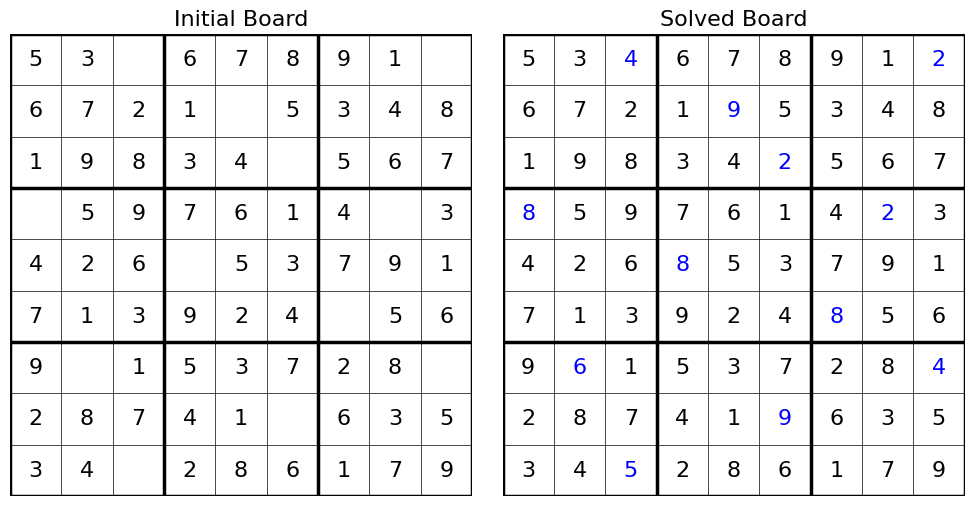

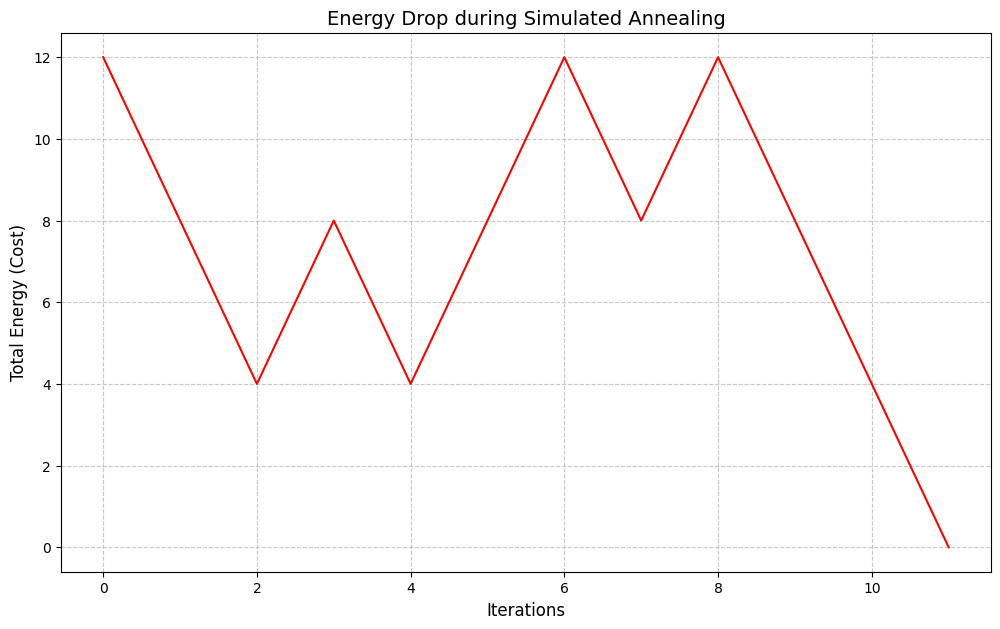

In [117]:
board = load_sudoku("./Sudoku_files/easy1.txt")

solved_board, iterations, energies = solve_sudoku_sa(
    board, 
    initial_temp=1000.0, 
    cooling_rate=0.997, 
    max_iterations=1000000
)

if energies[-1] == 0:
    print(f"SUCCESS! Found solution in {iterations} iterations.")
else:
    print(f"FAILED. Stuck with energy {energies[-1]} after {iterations} iterations.")
    
draw_sudoku(board, solved_board)
plot_energy_history(energies)

SUCCESS! Found solution in 1204 iterations.


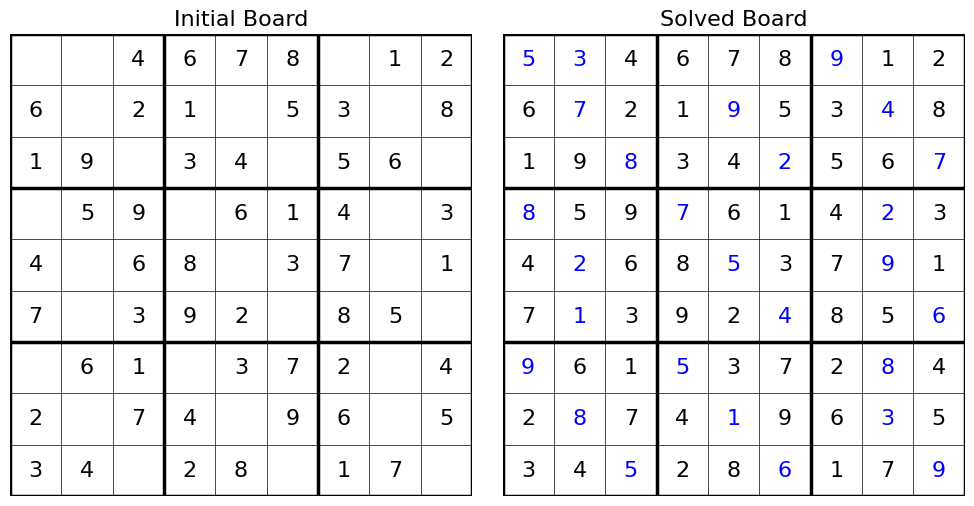

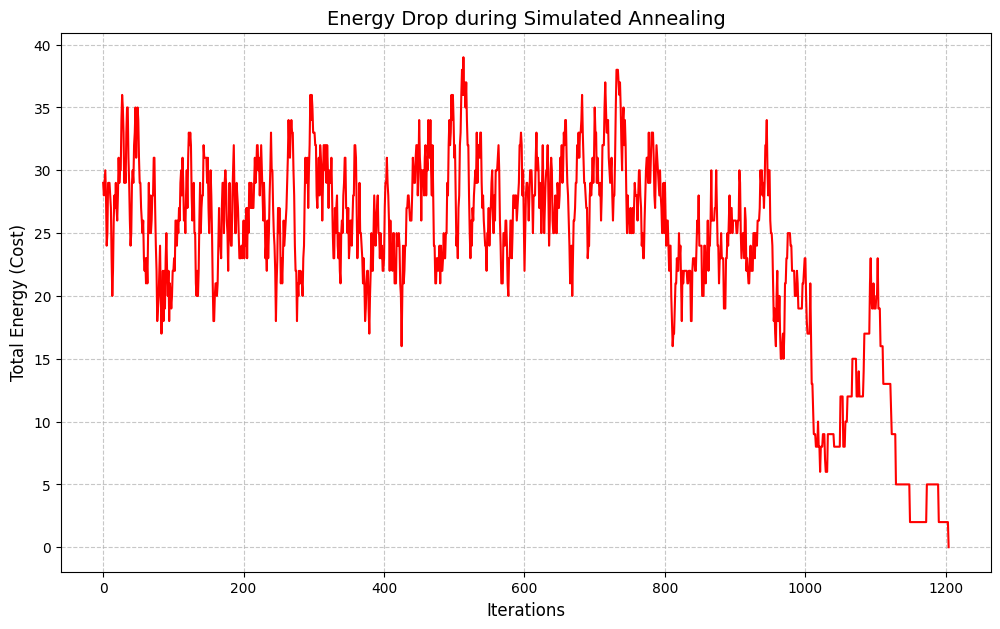

In [120]:
board = load_sudoku("./Sudoku_files/medium1.txt")

solved_board, iterations, energies = solve_sudoku_sa(
    board, 
    initial_temp=1001.0, 
    cooling_rate=0.994, 
    max_iterations=1000000
)

if energies[-1] == 0:
    print(f"SUCCESS! Found solution in {iterations} iterations.")
else:
    print(f"FAILED. Stuck with energy {energies[-1]} after {iterations} iterations.")
    
draw_sudoku(board, solved_board)
plot_energy_history(energies)

SUCCESS! Found solution in 10157 iterations.


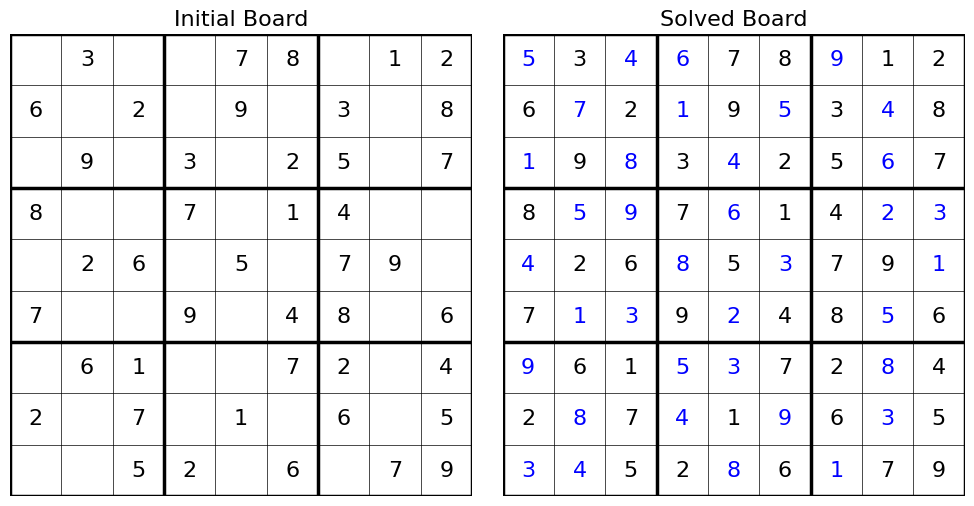

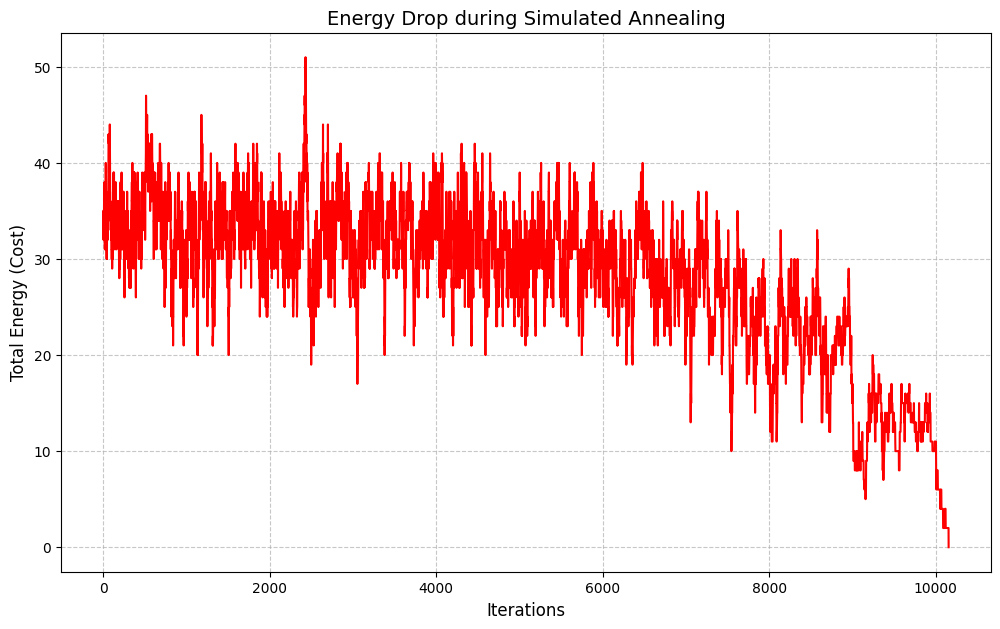

In [121]:
board = load_sudoku("./Sudoku_files/hard1.txt")

solved_board, iterations, energies = solve_sudoku_sa(
    board, 
    initial_temp=100.0, 
    cooling_rate=0.9995, 
    max_iterations=1000000
)

if energies[-1] == 0:
    print(f"SUCCESS! Found solution in {iterations} iterations.")
else:
    print(f"FAILED. Stuck with energy {energies[-1]} after {iterations} iterations.")
    
draw_sudoku(board, solved_board)
plot_energy_history(energies)

SUCCESS! Found solution in 4281 iterations.


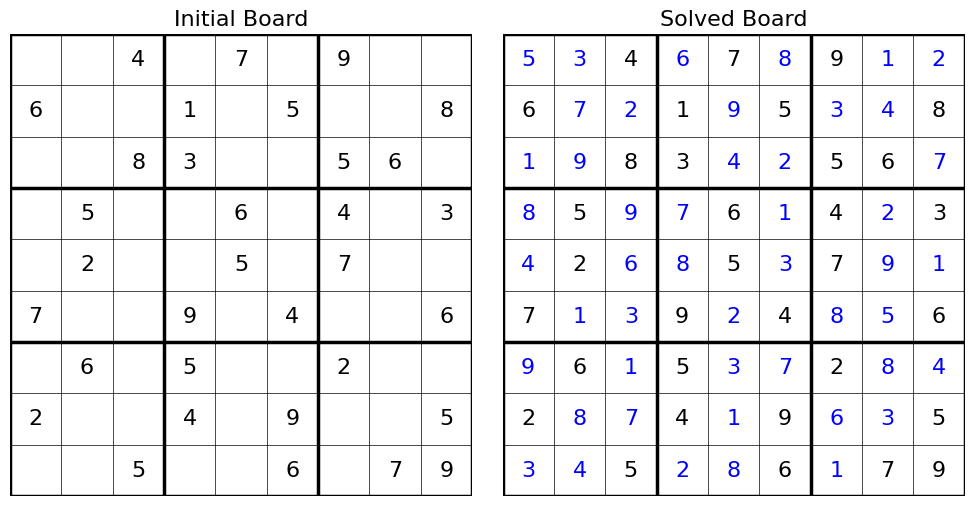

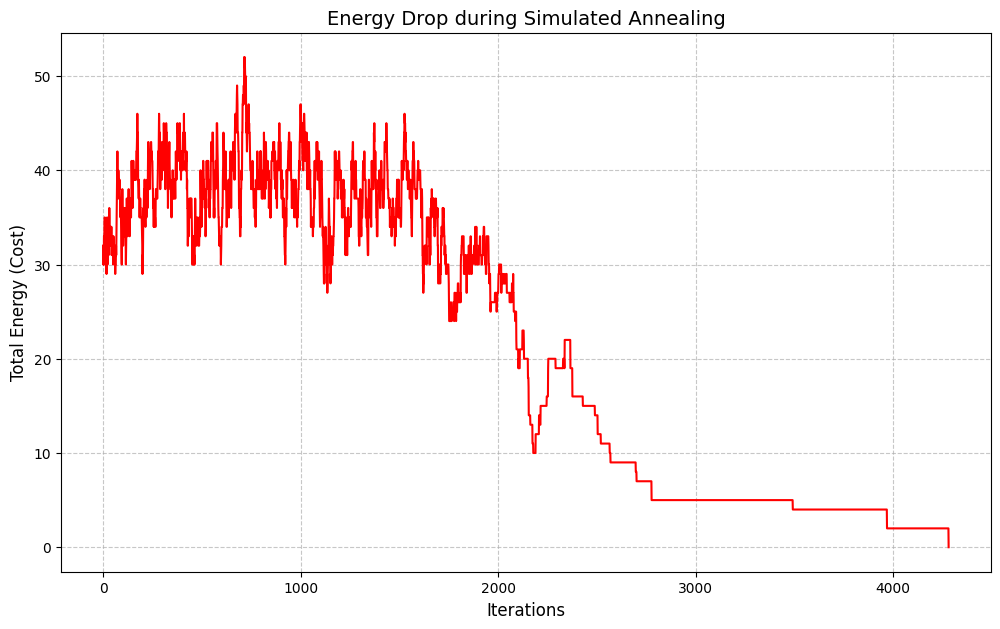

In [123]:
board = load_sudoku("./Sudoku_files/extrem1.txt")

solved_board, iterations, energies = solve_sudoku_sa(
    board, 
    initial_temp=100.0, 
    cooling_rate=0.9977, 
    max_iterations=1000000
)

if energies[-1] == 0:
    print(f"SUCCESS! Found solution in {iterations} iterations.")
else:
    print(f"FAILED. Stuck with energy {energies[-1]} after {iterations} iterations.")
    
draw_sudoku(board, solved_board)
plot_energy_history(energies)

<h1>Wykres  zależności liczby iteracji algorytmu od
liczby pustych miejsc na planszy.</h1>

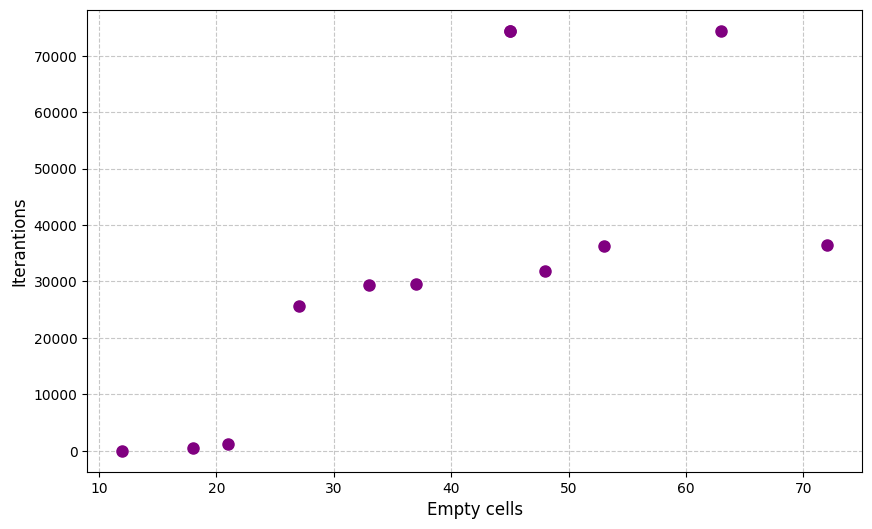

In [131]:
def analyze_sudoku_folder(folder_path):
    empty_cells_data = []
    iterations_data = []
    
    
    for filename in os.listdir(folder_path):
        if filename.endswith(".txt"):  
            filepath = os.path.join(folder_path, filename)
            
            board = load_sudoku(filepath)
            

            empty_count = sum(row.count(0) for row in board)
            
            

            solved_board, iterations, energies = solve_sudoku_sa(
                board, 
                initial_temp=5000.0, 
                cooling_rate=0.9997, 
                max_iterations=500000
            )
            
            empty_cells_data.append(empty_count)
            iterations_data.append(iterations)



    sorted_data = sorted(zip(empty_cells_data, iterations_data))
    


    sorted_empty = [item[0] for item in sorted_data]
    sorted_iters = [item[1] for item in sorted_data]

    plt.figure(figsize=(10, 6))
    
    plt.plot(sorted_empty, sorted_iters, marker='o', color='purple', linestyle='none',markersize=8)
    
    plt.xlabel("Empty cells", fontsize=12)
    plt.ylabel("Iterantions", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    


    plt.show()


analyze_sudoku_folder("./Sudoku_files")